In [167]:
from __future__ import annotations

import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt

In [168]:

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path('../DATA')
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'


if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('KAGGLE_ROOT  =', KAGGLE_ROOT)

SAMPLES_DIR = Path('./Samples_per_epoch/vanilla_gan')
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT = ../DATA
KAGGLE_ROOT  = ../DATA/ArtBench-10


In [169]:
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='../DATA/ArtBench-10'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [170]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [171]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0 

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),                          
    T.Normalize((0.5, 0.5, 0.5),         
                (0.5, 0.5, 0.5)),
])


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [172]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))


Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


## Visualize a sample grid

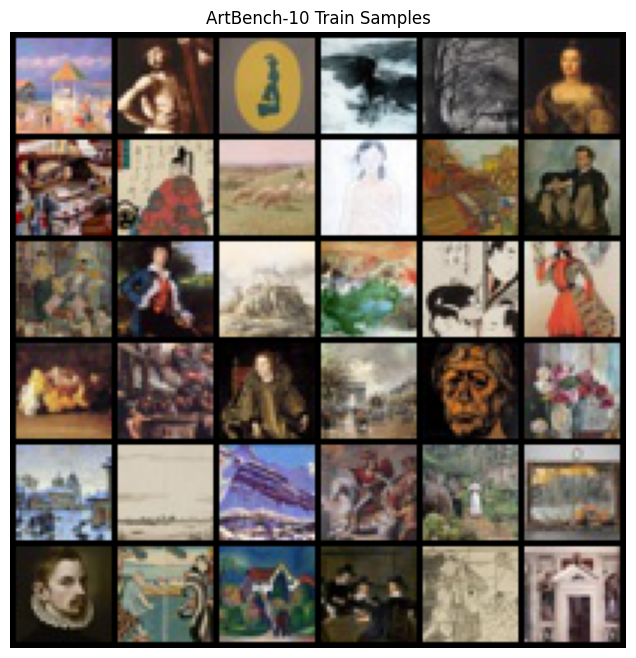

Labels: ['impressionism', 'renaissance', 'surrealism', 'realism', 'surrealism', 'baroque', 'surrealism', 'ukiyo_e', 'realism', 'post_impressionism', 'expressionism', 'impressionism', 'art_nouveau', 'impressionism', 'surrealism', 'expressionism', 'ukiyo_e', 'art_nouveau', 'realism', 'baroque', 'baroque', 'impressionism', 'expressionism', 'post_impressionism', 'post_impressionism', 'ukiyo_e', 'art_nouveau', 'baroque', 'realism', 'surrealism', 'renaissance', 'ukiyo_e', 'expressionism', 'baroque', 'ukiyo_e', 'renaissance']


In [173]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    x = (x * 0.5 + 0.5).clamp(0, 1)   

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

In [174]:
def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device('mps')
    return torch.device('cpu')

device=get_device()
print(device)

mps


## DCGAN (Deep Convolutional Generative Adversarial Networks)

In [175]:
import torch.nn as nn

class DCGenerator(nn.Module):
    def __init__(self, latent_dim=100, image_channels=3, ngf=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, image_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        z = z.view(z.size(0), self.latent_dim, 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self, image_channels=3, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(image_channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


def init_dcgan_weights(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

def plot_gan_losses(history, title='GAN losses'):
    plt.figure(figsize=(7, 4))
    plt.plot(history['d_loss'], label='Discriminator loss')
    plt.plot(history['g_loss'], label='Generator loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def save_checkpoint(generator, discriminator, history, checkpoint_path, latent_dim, channels, image_size):
    checkpoint_path = Path(checkpoint_path)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            'generator': generator.state_dict(),
            'discriminator': discriminator.state_dict(),
            'history': history,
            'config': {
                'latent_dim': latent_dim,
                'channels': channels,
                'image_size': image_size,
            },
        },
        checkpoint_path,
    )
    print('Saved checkpoint to', checkpoint_path)


@torch.no_grad()
def load_dcgan_generator_for_inference(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    cfg = ckpt['config']
    generator = DCGenerator(latent_dim=cfg['latent_dim'], image_channels=cfg['channels']).to(device)
    generator.load_state_dict(ckpt['generator'])
    generator.eval()
    return generator, cfg, ckpt.get('history', None)


In [176]:
from tqdm.auto import tqdm

def train_gan(generator, discriminator, loader, latent_dim, epochs=20, lr=2e-4):
    criterion = nn.BCEWithLogitsLoss()
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    history = {'g_loss': [], 'd_loss': []}
    generator.train()
    discriminator.train()

    for epoch in range(epochs):
        g_running = 0.0
        d_running = 0.0
        n_batches = 0

        for batch in tqdm(loader, desc=f'Epoch {epoch + 1}/{epochs}', leave=False):
            real = batch[0].to(device)
            bs = real.size(0)

            real_targets = torch.ones(bs, 1, device=device)
            fake_targets = torch.zeros(bs, 1, device=device)
            opt_d.zero_grad()
            d_real=criterion(discriminator(real),real_targets)
            z =torch.randn(bs,latent_dim,device=device)
            fake=generator(z)
            d_loss_fake=criterion(discriminator(fake.detach()),fake_targets)
            d_loss= d_real + d_loss_fake
            d_loss.backward()
            opt_d.step()

           
            opt_g.zero_grad()
            z = torch.randn(bs,latent_dim,device=device)
            fake=generator(z)
            g_loss = criterion(discriminator(fake),real_targets)
            g_loss.backward()
            opt_g.step()

       
            g_running += g_loss.item()
            d_running += d_loss.item()
            n_batches += 1

        history['g_loss'].append(g_running / max(n_batches, 1))
        history['d_loss'].append(d_running / max(n_batches, 1))

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"D loss: {history['d_loss'][-1]:.4f} | "
            f"G loss: {history['g_loss'][-1]:.4f}"
        )
        if epoch % 50 == 0 or epoch == epochs - 1:
            generator.eval()
            with torch.no_grad():
                z = torch.randn(64, latent_dim, device=device)
                samples = generator(z)
                samples= (samples * 0.5 + 0.5).clamp(0, 1)

            save_image(samples, SAMPLES_DIR / f"samples_ep{epoch:04d}.png", nrow=8)
            generator.train()

    return history

Epoch 1/300:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 01/300 | D loss: 0.2540 | G loss: 5.6705


Epoch 2/300:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 02/300 | D loss: 0.4344 | G loss: 5.3894


Epoch 3/300:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 298/300 | D loss: 0.0205 | G loss: 5.9408


Epoch 299/300:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 299/300 | D loss: 0.5071 | G loss: 5.3075


Epoch 300/300:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 300/300 | D loss: 0.5657 | G loss: 3.7996


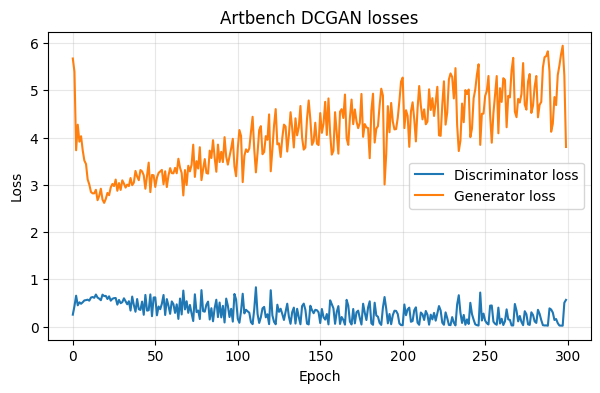

Saved checkpoint to models/artBenchDCGAN.pt


In [177]:
artBenchDCGAN_latent_dim = 100
artBenchDCGAN_epochs = 300
artBenchDCGAN_lr = 2e-4
artBenchDCGAN_channels=3

artBenchDCGAN_ckpt = Path('models/artBenchDCGAN.pt')

artBenchDCGAN_generator = DCGenerator(latent_dim=artBenchDCGAN_latent_dim,image_channels=artBenchDCGAN_channels,ngf=64).to(device)
artBenchDCGAN_discriminator = DCDiscriminator(image_channels=artBenchDCGAN_channels,ndf=64).to(device)

artBenchDCGAN_generator.apply(init_dcgan_weights)
artBenchDCGAN_discriminator.apply(init_dcgan_weights)

artBenchDCGAN_history = train_gan(
    generator=artBenchDCGAN_generator,
    discriminator=artBenchDCGAN_discriminator,
    loader=train_loader_from_csv,
    latent_dim=artBenchDCGAN_latent_dim,
    epochs=artBenchDCGAN_epochs,
    lr=artBenchDCGAN_lr,
)

plot_gan_losses(artBenchDCGAN_history, title='Artbench DCGAN losses')

save_checkpoint(
    generator=artBenchDCGAN_generator,
    discriminator=artBenchDCGAN_discriminator,
    history=artBenchDCGAN_history,
    checkpoint_path=artBenchDCGAN_ckpt,
    latent_dim=artBenchDCGAN_latent_dim,
    channels=artBenchDCGAN_channels,
    image_size=IMAGE_SIZE,
)

In [178]:
def show_image_grid(images, title=None, nrow=8, figsize=(8, 8), cmap='gray'):
    images = images.detach().cpu().float()
    images = (images * 0.5 + 0.5).clamp(0, 1) 
    
    grid = make_grid(images, nrow=nrow)
    np_grid = grid.permute(1, 2, 0).numpy()

    plt.figure(figsize=figsize)
    if np_grid.shape[-1] == 1:
        plt.imshow(np_grid[..., 0], cmap=cmap)
    else:
        plt.imshow(np_grid)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [179]:
@torch.no_grad()
def generate_images(generator, latent_dim, n_samples, device, seed):
    torch.manual_seed(seed)

    z = torch.randn(n_samples, latent_dim, device=device)

    generator.eval()
    images = generator(z).cpu()


    return images


Evaluation protocol: {'feature_batch_size': 32, 'fid_kid_samples': 5000, 'num_runs': 10, 'subset_size': 100, 'num_subsets': 50, 'generation_seed': 123, 'vis_count': 64, 'noise_seed': 321}


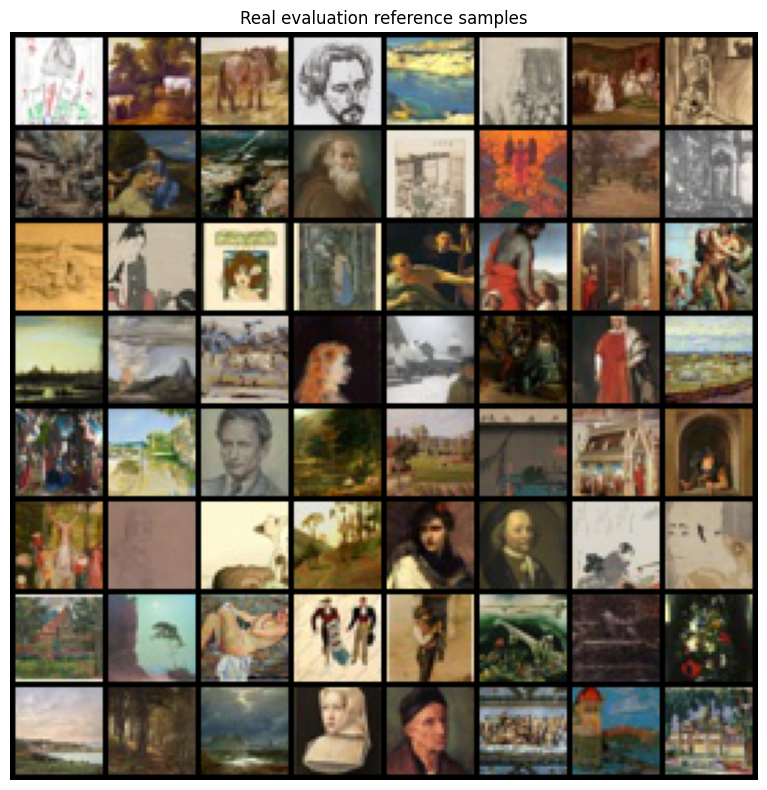

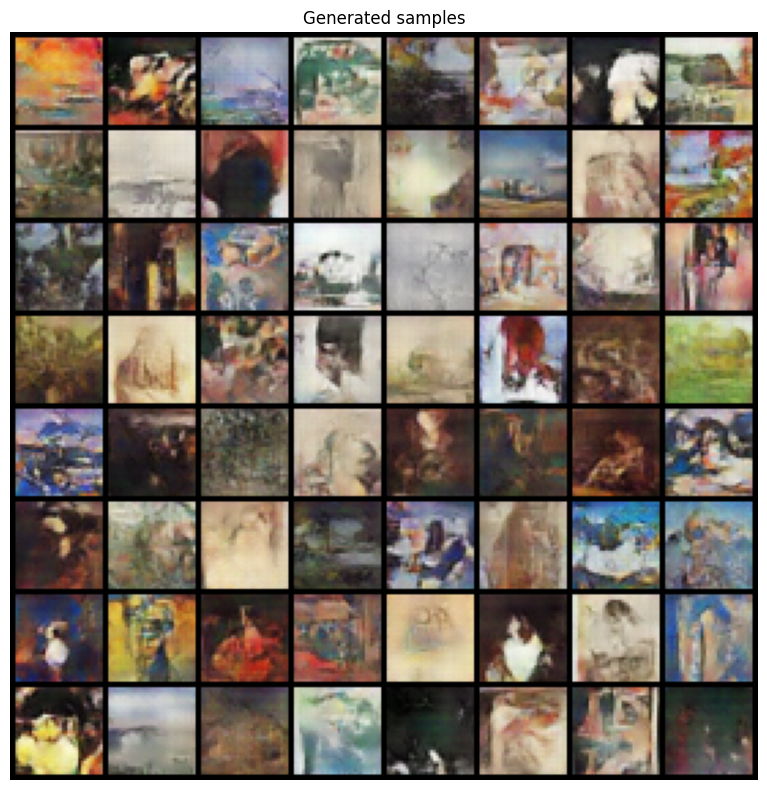

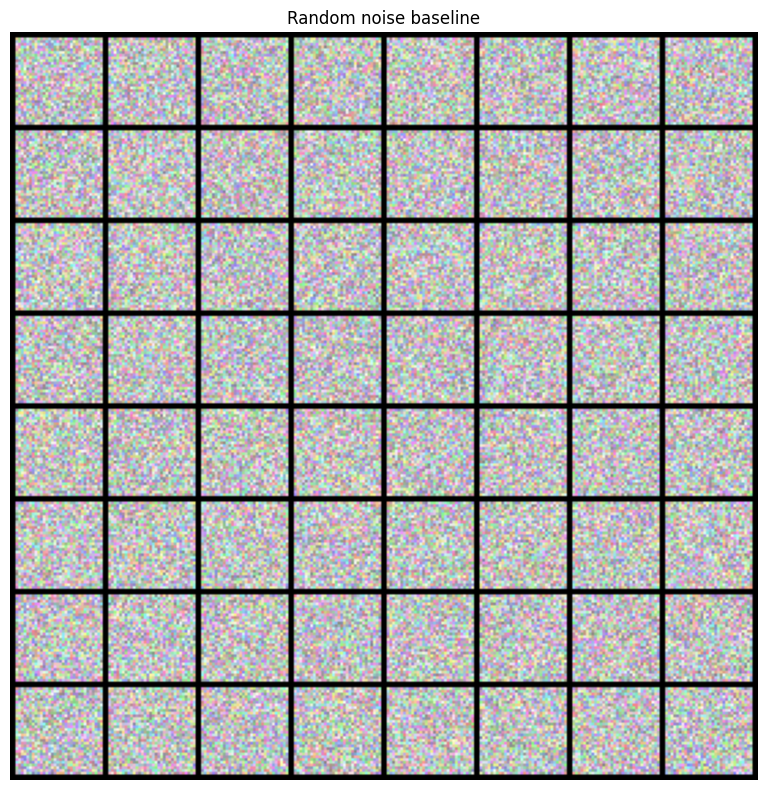

In [180]:
evaluation_config = {
    'feature_batch_size': 32,
    'fid_kid_samples':    5000,
    'num_runs':           10,
    'subset_size':        100,
    'num_subsets':        50,
    'generation_seed':    123,
    'vis_count':          64,    
    'noise_seed':         321,
}

vis_n = evaluation_config['vis_count']

real_batch = next(iter(train_loader_from_csv))
real_vis_images = real_batch[0][:vis_n]

generated_vis = generate_images(artBenchDCGAN_generator,artBenchDCGAN_latent_dim,vis_n,device=device,seed=evaluation_config['generation_seed'])

noise_gen = torch.Generator(device='cpu').manual_seed(evaluation_config['noise_seed'])
noise_vis = torch.rand(real_vis_images.shape, generator=noise_gen)

print('Evaluation protocol:', evaluation_config)
show_image_grid(real_vis_images, title='Real evaluation reference samples', nrow=8, figsize=(8, 8))
show_image_grid(generated_vis, title='Generated samples', nrow=8, figsize=(8, 8))
show_image_grid(noise_vis, title='Random noise baseline', nrow=8, figsize=(8, 8))


In [181]:
import numpy as np
from scipy import linalg
from torchvision.models import inception_v3, Inception_V3_Weights
import torch


def load_inception(device):
    model = inception_v3(weights=Inception_V3_Weights.DEFAULT)
    model.fc = torch.nn.Identity()
    model.eval().to(device)
    return model

@torch.no_grad()
def get_inception_features(images: torch.Tensor, model, device, batch_size=32) -> np.ndarray:
    imgs = images.float()
    if imgs.min() < 0:
        imgs = (imgs * 0.5 + 0.5).clamp(0, 1)
    imgs = torch.nn.functional.interpolate(
        imgs, size=(299, 299), mode='bilinear', align_corners=False
    )
    feats = []
    for i in range(0, len(imgs), batch_size):
        feats.append(model(imgs[i:i+batch_size].to(device)).cpu().numpy())
    return np.concatenate(feats, axis=0)

# ── FID ───────────────────────────────────────────────────────────────────────
def compute_fid(real_feats: np.ndarray, fake_feats: np.ndarray) -> float:
    mu1, sigma1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

# ── KID (50 subsets × 100) ────────────────────────────────────────────────────
def compute_kid(real_feats: np.ndarray, fake_feats: np.ndarray,num_subsets=50, subset_size=100) -> tuple:
    subset_size = min(subset_size, len(real_feats), len(fake_feats))
    d = real_feats.shape[1]
    scores = []
    for _ in range(num_subsets):
        r = real_feats[np.random.choice(len(real_feats), subset_size, replace=False)]
        f = fake_feats[np.random.choice(len(fake_feats), subset_size, replace=False)]
        kxx = (r @ r.T / d + 1) ** 3
        kyy = (f @ f.T / d + 1) ** 3
        kxy = (r @ f.T / d + 1) ** 3
        mmd = (kxx.sum() - np.diag(kxx).sum()) / (subset_size * (subset_size - 1)) \
            + (kyy.sum() - np.diag(kyy).sum()) / (subset_size * (subset_size - 1)) \
            - 2 * kxy.mean()
        scores.append(mmd)
    return float(np.mean(scores)), float(np.std(scores))

def run_evaluation(generator, latent_dim, train_loader, device, cfg: dict):
    n        = cfg['fid_kid_samples']     # 5000
    n_runs   = cfg['num_runs']            # 10
    n_sub    = cfg['num_subsets']         # 50
    sub_size = cfg['subset_size']         # 100
    bs       = cfg['feature_batch_size']  # 32

    print(f"Protocol: {n} generated vs {n} real  |  {n_runs} runs  |  KID: {n_sub} subsets × {sub_size}")

    inception = load_inception(device)

    all_real = []
    for batch in train_loader:
        all_real.append(batch[0])
        if sum(x.shape[0] for x in all_real) >= n:
            break
    all_real = torch.cat(all_real, dim=0)[:n]

    feats_real = get_inception_features(all_real, inception, device, bs)

    fid_scores = []
    kid_means  = []
    kid_stds   = []

    for run in range(n_runs):
        seed = cfg['generation_seed'] + run
        print(f"\n── Run {run+1}/{n_runs}  (seed={seed}) ──────────────────────")
        gen_imgs  = generate_images(generator, latent_dim, n, device, seed=seed)

        print("  A extrair features das imagens geradas...")
        feats_gen = get_inception_features(gen_imgs, inception, device, bs)

        fid_val            = compute_fid(feats_real, feats_gen)
        kid_mean, kid_std  = compute_kid(feats_real, feats_gen, n_sub, sub_size)

        fid_scores.append(fid_val)
        kid_means.append(kid_mean)
        kid_stds.append(kid_std)

        print(f"  FID = {fid_val:.4f}  |  KID = {kid_mean:.6f} ± {kid_std:.6f}")

    print("\n" + "="*50)
    print("RESULTADOS FINAIS  (mean ± std  across 10 runs)")
    print("="*50)
    print(f"  FID : {np.mean(fid_scores):.4f} ± {np.std(fid_scores):.4f}")
    print(f"  KID : {np.mean(kid_means):.6f} ± {np.std(kid_means):.6f}")
    print("="*50)

    return {
        'fid_mean': np.mean(fid_scores), 'fid_std': np.std(fid_scores),
        'kid_mean': np.mean(kid_means),  'kid_std': np.std(kid_means),
        'fid_per_run': fid_scores,
        'kid_per_run': kid_means,
    }


results = run_evaluation(
    generator    = artBenchDCGAN_generator,
    latent_dim   = artBenchDCGAN_latent_dim,
    train_loader = train_loader_from_csv,
    device       = device,
    cfg          = evaluation_config,
)

Protocol: 5000 generated vs 5000 real  |  10 runs  |  KID: 50 subsets × 100

── Run 1/10  (seed=123) ──────────────────────
  A extrair features das imagens geradas...
  FID = 22.1739  |  KID = 0.013302 ± 0.003763

── Run 2/10  (seed=124) ──────────────────────
  A extrair features das imagens geradas...
  FID = 22.0796  |  KID = 0.014889 ± 0.004748

── Run 3/10  (seed=125) ──────────────────────
  A extrair features das imagens geradas...
  FID = 22.5654  |  KID = 0.015221 ± 0.003847

── Run 4/10  (seed=126) ──────────────────────
  A extrair features das imagens geradas...
  FID = 21.9428  |  KID = 0.013326 ± 0.003511

── Run 5/10  (seed=127) ──────────────────────
  A extrair features das imagens geradas...
  FID = 22.1157  |  KID = 0.014195 ± 0.004573

── Run 6/10  (seed=128) ──────────────────────
  A extrair features das imagens geradas...
  FID = 21.9438  |  KID = 0.014922 ± 0.004907

── Run 7/10  (seed=129) ──────────────────────
  A extrair features das imagens geradas...
  FI